# Drought Prediction

*Martin Vonk - 2025*

This notebooks shows two applications for drought prediction. One where the time series of the groundwater head is predicted into the future based on the available meteorological stresses. The SGI is then computed on the modelled groundwater head. The othera application shows the prediction of the drought based on the SPEI statistics over previous reference period

## Required packages

In [56]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import pastas as ps
import scipy.stats as scs

import spei as si  # si for standardized index

si.show_versions()

'python: 3.13.5\nspei: 0.8.1\nnumpy: 2.3.2\nscipy: 1.16.1\nmatplotlib: 3.10.6\npandas: 2.3.2'

## Import time series

Time series are imported using the package hydropandas. Enddate is by default yesterday. The head time series is obtained from KNMI meteo station De Bilt and Pastas test dataset.

In [2]:
# import hydropandas as hpd

# today = datetime.date.today()
# yesterday = (today - datetime.timedelta(days=1)).strftime("%Y-%m-%d")
# prec = (
#     hpd.PrecipitationObs.from_knmi(
#         meteo_var="RH", stn=260, startdate="1959-07-01", enddate=yesterday
#     )
#     .multiply(1e3)
#     .squeeze()
# )
# prec.index = prec.index.normalize()
# evap = (
#     hpd.EvaporationObs.from_knmi(
#         meteo_var="EV24", stn=260, startdate="1959-07-01", enddate=yesterday
#     )
#     .multiply(1e3)
#     .squeeze()
# )
# evap.index = evap.index.normalize()


df = pd.read_csv("data/DEBILT.csv", index_col=0, parse_dates=True)
prec = df["Prec [m/d] 260_DEBILT"].multiply(1e3).rename("prec")
evap = df["Evap [m/d] 260_DEBILT"].multiply(1e3).rename("evap")
head = df["Head [m] B32C0572_DEBILT"].rename("B32C0572").dropna()
today = df.index[-1]
yesterday = df.index[-2]

## Predicting the head and SGI with a time series model

The SGI is calculated using a [Pastas](https://github.com/pastas/pastas) time series model since the original head time series is too short. We'll  The application of time series models for extrapolating groundwater time series is discussed in [Brakkee et al (2022)](https://hess.copernicus.org/articles/26/551/2022/hess-26-551-2022.html).


Fit report B32C0572                 Fit Statistics
nfev     48                     EVP          79.61
nobs     1187                   R2            0.80
noise    False                  RMSE          0.11
tmin     1970-07-01 00:00:00    AICc      -5305.22
tmax     2020-12-28 00:00:00    BIC       -5264.71
freq     D                      Obj           6.71
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No
solver   LeastSquares           weights        Yes

Parameters (8 optimized)
                   optimal     initial   vary
recharge_A        0.468701    0.443936   True
recharge_a      170.731978   10.000000   True
recharge_srmax  103.698300  250.000000   True
recharge_lp       0.250000    0.250000  False
recharge_ks     145.218574  100.000000   True
recharge_gamma    1.470284    2.000000   True
recharge_kv       1.999721    1.000000   True
recharge_simax    2.000000    2.000000  False
recharge_gf       0.250351    1.000000   True
cons

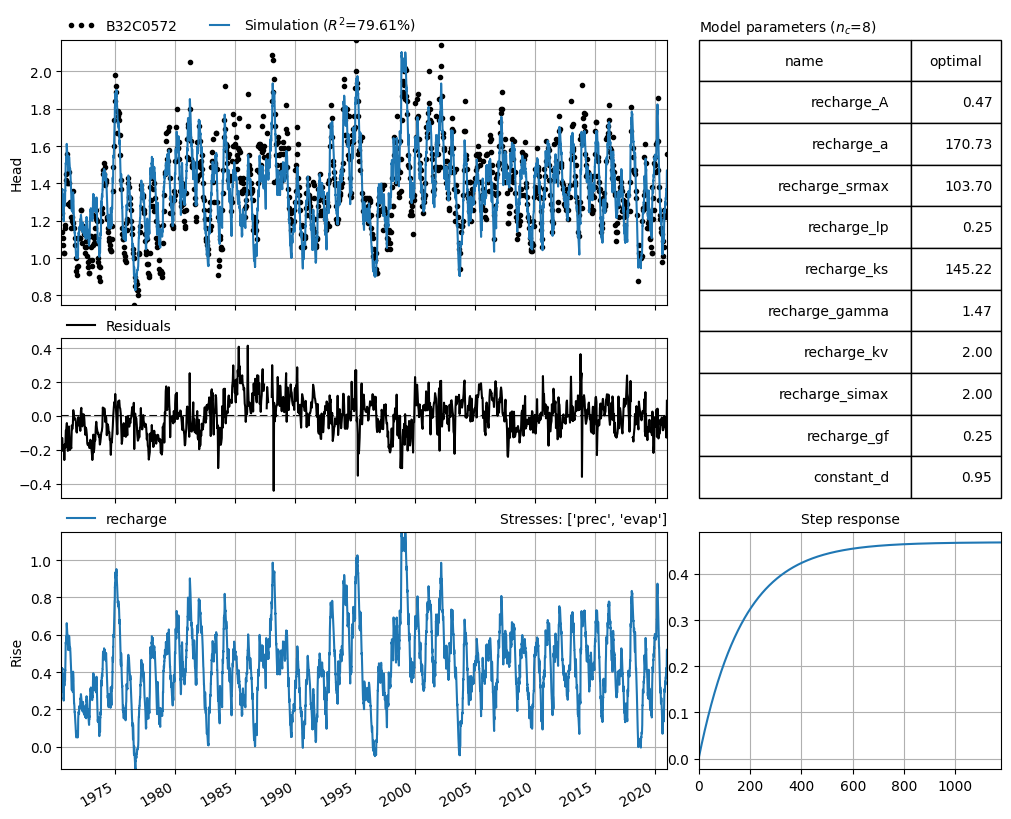

In [5]:
ml = ps.Model(head)
rm = ps.RechargeModel(
    prec, evap, ps.Exponential(), recharge=ps.rch.FlexModel(gw_uptake=True)
)
ml.add_stressmodel(rm)
ml.solve(tmin="1970-07-01", report=True)
_ = ml.plots.results(figsize=(10.0, 8.0))

### Calculate SGI based on time series model

In [6]:
gws = ml.simulate(tmin="1990-07-01", tmax=yesterday)
sgi = si.sgi(gws, fit_freq="MS")

### Compare three drought-indices (SPI, SPEI, SGI) in plot

In [15]:
# Compute the SPI and SPEI time series on monthly basis
spi1 = si.spi(prec, timescale=30, dist=scs.gamma, fit_freq="MS")
spei1 = si.spei((prec - evap), timescale=30, dist=scs.fisk, fit_freq="MS")

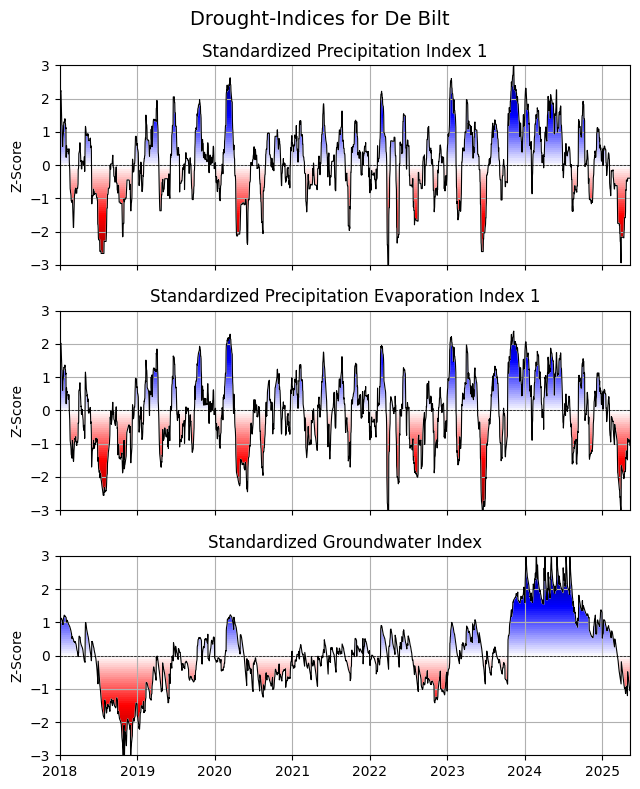

In [13]:
xlim = pd.to_datetime(["2018-01-01", df.index[-1]])

fig, axs = plt.subplot_mosaic(
    [["SPI"], ["SPEI"], ["SGI"]], figsize=(6.5, 8), sharex=True
)
si.plot.si(spi1, ax=axs["SPI"], add_category=False)
si.plot.si(spei1, ax=axs["SPEI"], add_category=False)
si.plot.si(sgi, ax=axs["SGI"], add_category=False)
[(axs[x].grid(), axs[x].set(xlim=xlim, ylabel="Z-Score")) for x in axs]


axs["SPI"].set_title("Standardized Precipitation Index 1")
axs["SPEI"].set_title("Standardized Precipitation Evaporation Index 1")
axs["SGI"].set_title("Standardized Groundwater Index")
fig.suptitle("Drought-Indices for De Bilt", fontsize=14)
fig.tight_layout()
# fig.savefig('Drought_Index_Bilt.png', dpi=600, bbox_inches='tight')

### Compare SGI Kernel Density Estimate for one month

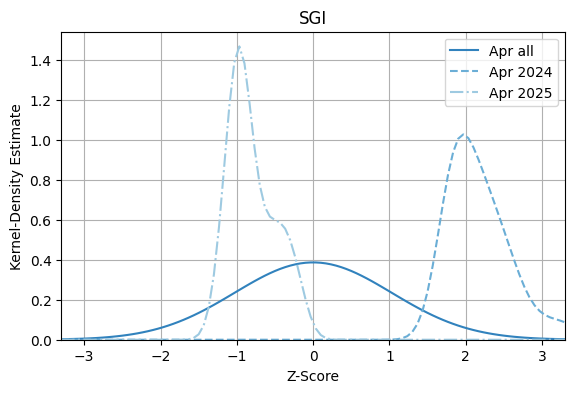

In [10]:
ax = si.plot.monthly_density(
    sgi, years=[today.year - 1, today.year], months=[today.month - 1]
)
ax.set_xlabel("Z-Score")
ax.set_title("SGI");

## Predicting drought by calibration over a reference period

It might be usefull to fit the SPEI on a different window (calibration period) and predic the drought using those parameters over a different time period. The example below shows how that's done.

In [66]:
# get precipitation excess and settings
pex = prec - evap
timescale = 180
dist = scs.fisk
fit_freq = "MS"

Now lets compute the SPEI with the calibraiton period the full lenght of available data in the time series.

In [ ]:
full_spei = si.SI(pex, timescale=timescale, dist=dist, fit_freq=fit_freq)
full_spei.fit_distribution()
spei_full = full_spei.norm_ppf()

And now compute the SPEI over a shorter calibration period, and predict the SPEI over another period using the parameters from the fitted distribution over the calibration period.

In [ ]:
tmax = pd.Timestamp("1990-01-01")
ref_spei = si.SI(pex.loc[:tmax], timescale=timescale, dist=dist, fit_freq=fit_freq)
ref_spei.fit_distribution()
spei_ref = ref_spei.norm_ppf()
spei_pred = ref_spei.predict(pex.loc[tmax:])

Look at the difference

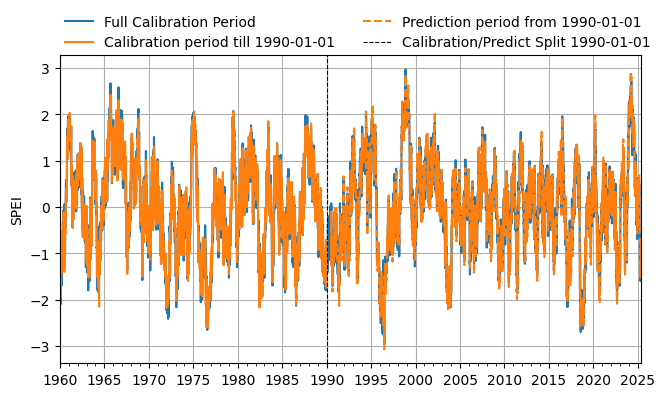

In [79]:
f, ax = plt.subplots(figsize=(7.5, 4.0))

ax.plot(spei_full.index, spei_full, label="Full Calibration Period", color="C0")
ax.plot(
    spei_ref.index, spei_ref, label=f"Calibration period till {tmax.date()}", color="C1"
)
ax.plot(
    spei_pred.index,
    spei_pred,
    label=f"Prediction period from {tmax.date()}",
    color="C1",
    linestyle="--",
)
ax.axvline(
    tmax,
    color="k",
    linewidth=0.8,
    linestyle="--",
    label=f"Calibration/Predict Split {tmax.date()}",
)
ax.legend(loc=(0, 1), frameon=False, ncol=2)
ax.set_ylabel("SPEI")
ax.xaxis.set_major_locator(mpl.dates.YearLocator(5))
ax.xaxis.set_minor_locator(mpl.dates.YearLocator(1))
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(1))
ax.set_xlim(spei_full.index[0], spei_full.index[-1])
ax.grid(True)